Week 2 Assignment CEI 
Name - Himanshu Singh Gahlot
College - JECRC Foundation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [2]:
print(df.dtypes)
print()
print('nulls:')
print(df.isnull().sum())

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

nulls:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


okay so no nulls at all which is good. 2640 rows, 5 models, 4 regions. the price column has a pretty wide range so different models are clearly priced very differently

Now i will do Preprocessing of data

In [3]:
# building a date column so i can work with time properly
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').reset_index(drop=True)

# quick sanity check
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Unique regions:', df['Region'].unique())
print('Unique models:', df['Model'].unique())

Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Unique regions: ['Asia' 'Middle East' 'North America' 'Europe']
Unique models: ['Model Y' 'Model 3' 'Cybertruck' 'Model S' 'Model X']


In [4]:
df_enc = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)
print('Shape after encoding:', df_enc.shape)
df_enc.head()

Shape after encoding: (2640, 19)


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,False,False,False,False,False,False,True,False,True
1,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,False,True,False,True,False,False,False,False,False
2,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,False,True,False,False,False,False,False,True,False
3,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,False,False,True,False,False,False,False,False,False
4,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,False,False,False,True,False,False,False,False,True


In [5]:
df[['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Range_km']].describe()

,Estimated_Deliveries,Production_Units,Avg_Price_USD,Range_km
count,2640.000000,2640.000000,2640.000000,2640.000000
mean,9922.199621,10655.847348,84907.340330,500.257576
std,3935.950093,4260.600858,20123.258036,120.868549
min,48.000000,50.000000,50003.700000,330.000000
25%,7292.000000,7828.250000,67726.365000,418.000000
50%,9857.000000,10546.500000,85058.510000,470.000000
75%,12510.250000,13469.000000,102373.042500,586.250000
max,25704.000000,28939.000000,119965.360000,719.000000


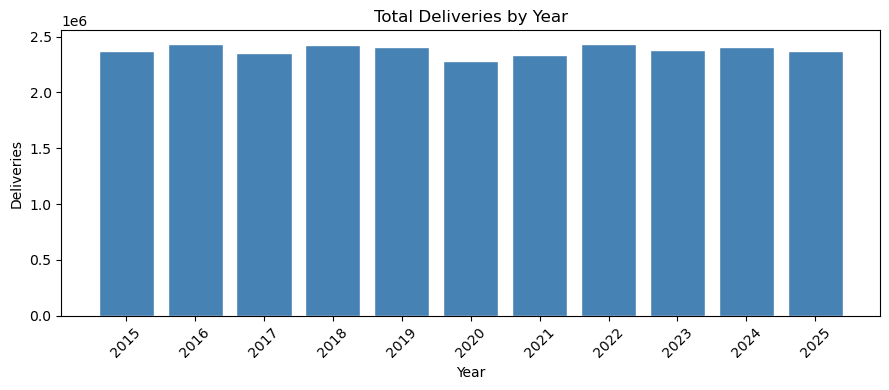

In [6]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(9, 4))
plt.bar(yearly['Year'], yearly['Estimated_Deliveries'], color='steelblue', edgecolor='white')
plt.title('Total Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.xticks(yearly['Year'], rotation=45)
plt.tight_layout()
plt.show()

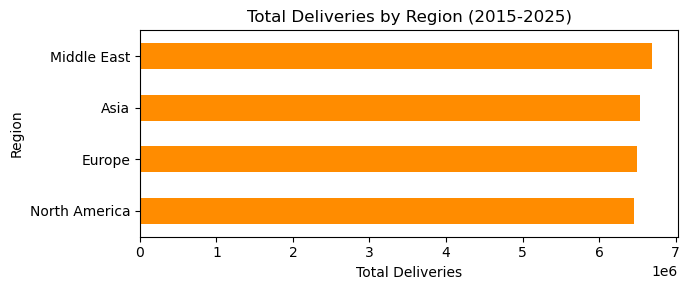

In [7]:
region_totals = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=True)

region_totals.plot(kind='barh', figsize=(7, 3), color='darkorange')
plt.title('Total Deliveries by Region (2015-2025)')
plt.xlabel('Total Deliveries')
plt.tight_layout()
plt.show()

In [8]:
model_stats = df.groupby('Model').agg(
    total_deliveries=('Estimated_Deliveries', 'sum'),
    avg_price=('Avg_Price_USD', 'mean')
).sort_values('total_deliveries', ascending=False)

print(model_stats)

            total_deliveries     avg_price
Model                                     
Model S              5380385  85185.401269
Model 3              5321919  84528.004223
Model Y              5225284  86081.211061
Model X              5157240  84243.212936
Cybertruck           5109779  84498.872159


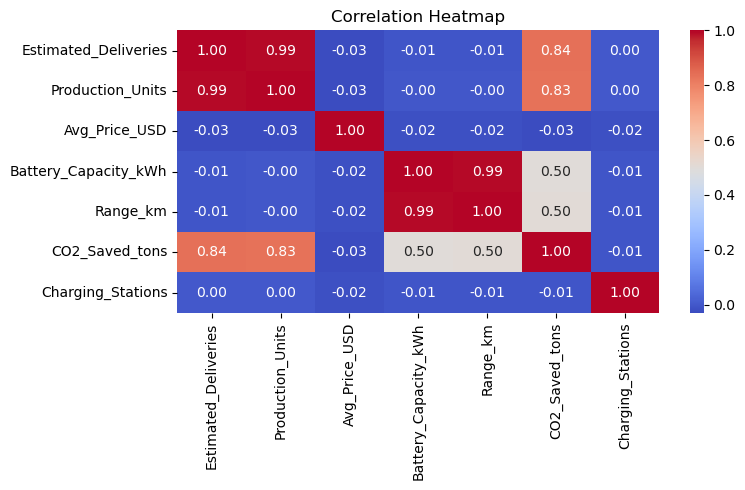

In [9]:
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

corr = df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

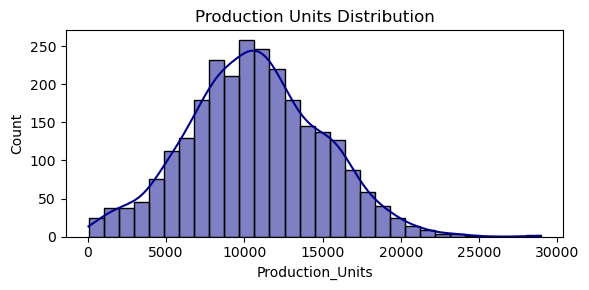

skewness: 0.13
kurtosis: 0.016


In [10]:
plt.figure(figsize=(6, 3))
sns.histplot(df['Production_Units'], bins=30, kde=True, color='darkblue')
plt.title('Production Units Distribution')
plt.tight_layout()
plt.show()

print('skewness:', round(df['Production_Units'].skew(), 3))
print('kurtosis:', round(df['Production_Units'].kurt(), 3))

In [11]:
df_enc['Surplus'] = df_enc['Production_Units'] - df_enc['Estimated_Deliveries']
df_enc['Price_per_km'] = df_enc['Avg_Price_USD'] / df_enc['Range_km']
roll = df_enc['Production_Units'].rolling(window=3).mean()
df_enc['Roll3_Prod'] = roll.fillna(df_enc['Production_Units'].median())

print('New features added: Surplus, Price_per_km, Roll3_Prod')
df_enc[['Date', 'Production_Units', 'Surplus', 'Price_per_km', 'Roll3_Prod']].head(10)

New features added: Surplus, Price_per_km, Roll3_Prod


,Date,Production_Units,Surplus,Price_per_km,Roll3_Prod
0,2015-01-01,13885,1439,162.303324,10546.500000
1,2015-01-01,12752,1306,151.852721,10546.500000
2,2015-01-01,9344,541,306.216012,11993.666667
3,2015-01-01,6802,435,228.676078,9632.666667
4,2015-01-01,9165,370,192.957741,8437.000000
5,2015-01-01,2465,304,162.068935,6144.000000
6,2015-01-01,13302,1316,201.107418,8310.666667
7,2015-01-01,8878,45,246.534555,8215.000000
8,2015-01-01,9528,82,254.327195,10569.333333
9,2015-01-01,4736,386,112.108484,7714.000000


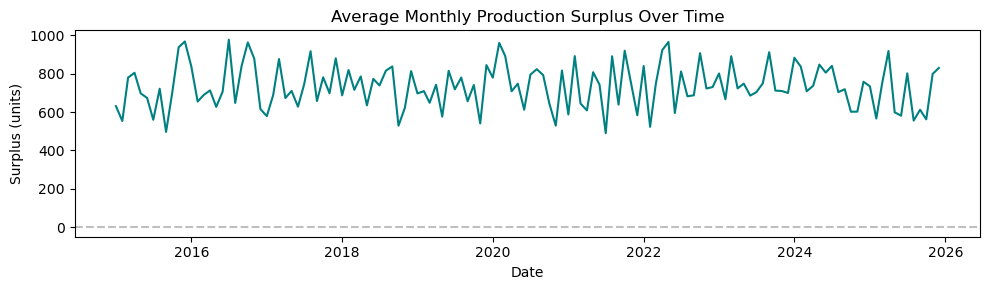

In [12]:
surplus_monthly = df_enc.groupby('Date')['Surplus'].mean()

plt.figure(figsize=(10, 3))
plt.plot(surplus_monthly.index, surplus_monthly.values, color='teal')
plt.axhline(0, linestyle='--', color='gray', alpha=0.5)
plt.title('Average Monthly Production Surplus Over Time')
plt.xlabel('Date')
plt.ylabel('Surplus (units)')
plt.tight_layout()
plt.show()

skewness is 0.13 so basically normal, no need to do any transformation

trying LR first just to see how a simple model does, then RF after

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

drop_cols = ['Production_Units', 'CO2_Saved_tons', 'Surplus', 'Date', 'Year', 'Month']
X = df_enc.drop(columns=drop_cols)
y = df_enc['Production_Units']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)
print(f'train size: {X_train.shape}, test size: {X_test.shape}')

train size: (2112, 16), test size: (528, 16)


In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_r2   = r2_score(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print(f'Linear Regression')
print(f'  R2  : {lr_r2:.4f}')
print(f'  RMSE: {lr_rmse:.2f} units')

Linear Regression
  R2  : 0.9865
  RMSE: 458.91 units


Linear regression already gives R2 = 0.9865 which is surprisingly strong let's see if Random Forest can do it better or not.

In [15]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_r2   = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print(f'Random Forest (default)')
print(f'  R2  : {rf_r2:.4f}')
print(f'  RMSE: {rf_rmse:.2f} units')

Random Forest (default)
  R2  : 0.9851
  RMSE: 482.77 units


hmm RF is actually slightly worse than LR here, interesting. both are close though

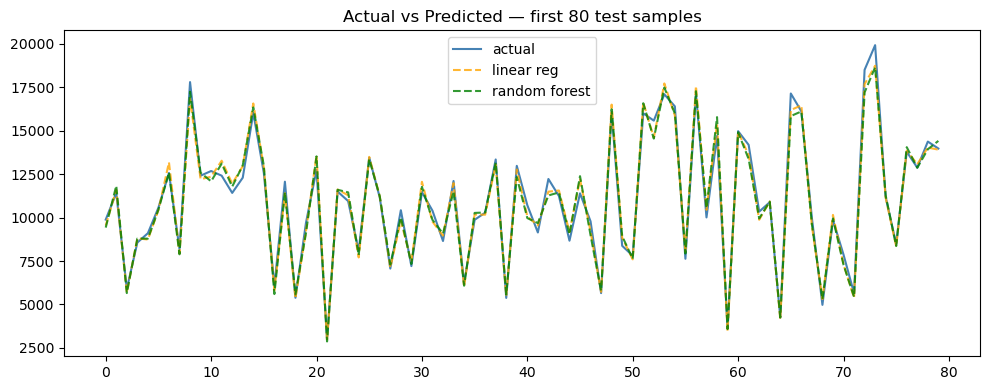

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.values[:80], label='actual', color='steelblue')
plt.plot(lr_preds[:80], label='linear reg', color='orange', linestyle='--', alpha=0.8)
plt.plot(rf_preds[:80], label='random forest', color='green', linestyle='--', alpha=0.8)
plt.title('Actual vs Predicted — first 80 test samples')
plt.legend()
plt.tight_layout()
plt.show()

Both model performing almost same .

 Now we will do Hyperparameter Tuning


In [17]:
depths = [3, 5, 8, 12, 20, None]  
results = []

for d in depths:
    mod = RandomForestRegressor(n_estimators=100, max_depth=d, random_state=42)
    mod.fit(X_train, y_train)
    tr_r2 = r2_score(y_train, mod.predict(X_train))
    te_r2 = r2_score(y_test,  mod.predict(X_test))
    te_rmse = np.sqrt(mean_squared_error(y_test, mod.predict(X_test)))
    results.append({'depth': str(d), 'train_r2': tr_r2, 'test_r2': te_r2, 'test_rmse': te_rmse})
    print(f"depth={str(d):4s}  train_r2={tr_r2:.4f}  test_r2={te_r2:.4f}  rmse={te_rmse:.1f}")

depth=3     train_r2=0.9680  test_r2=0.9659  rmse=729.8
depth=5     train_r2=0.9902  test_r2=0.9856  rmse=474.5
depth=8     train_r2=0.9947  test_r2=0.9854  rmse=477.1
depth=12    train_r2=0.9978  test_r2=0.9853  rmse=479.6
depth=20    train_r2=0.9982  test_r2=0.9852  rmse=480.5
depth=None  train_r2=0.9982  test_r2=0.9851  rmse=482.8


At deapth 5 R2 score is best we will take this depth to test rmse

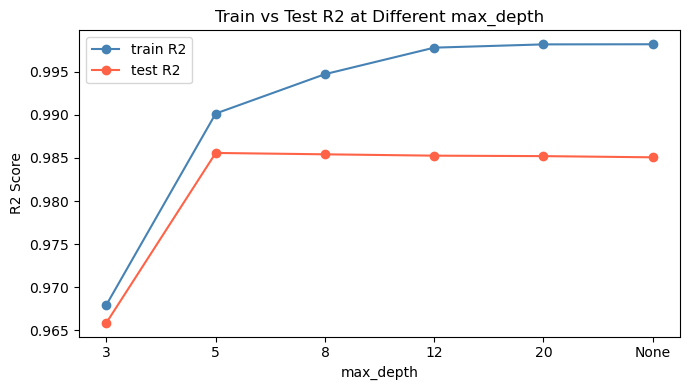

In [18]:
res_df = pd.DataFrame(results)

plt.figure(figsize=(7, 4))
plt.plot(res_df['depth'], res_df['train_r2'], marker='o', label='train R2', color='steelblue')
plt.plot(res_df['depth'], res_df['test_r2'],  marker='o', label='test R2',  color='tomato')
plt.title('Train vs Test R2 at Different max_depth')
plt.xlabel('max_depth')
plt.ylabel('R2 Score')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
best_row = min(results, key=lambda r: r['test_rmse'])
best_d = None if best_row['depth'] == 'None' else int(best_row['depth'])
print(f"best depth: {best_d}  (test RMSE: {best_row['test_rmse']:.1f})")

final_rf = RandomForestRegressor(n_estimators=100, max_depth=best_d, random_state=42)
final_rf.fit(X_train, y_train)
final_preds = final_rf.predict(X_test)
print(f"Final model R2: {r2_score(y_test, final_preds):.4f}")

best depth: 5  (test RMSE: 474.5)
Final model R2: 0.9856


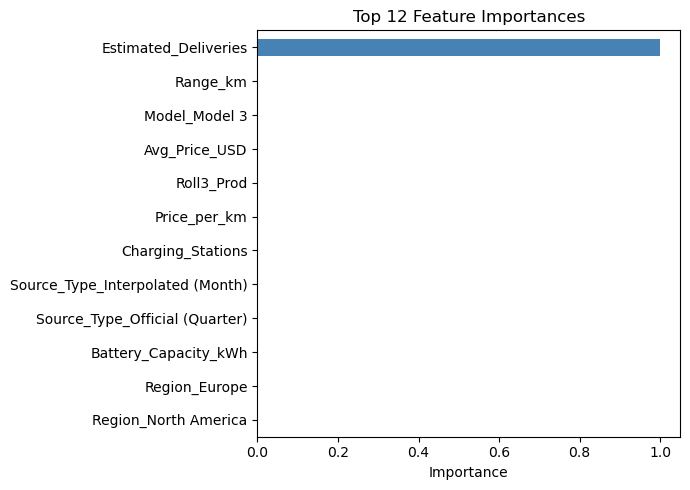

In [20]:
imp = pd.Series(final_rf.feature_importances_, index=X.columns).sort_values()

imp.tail(12).plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title('Top 12 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

now the ARIMA part, this is what we covered in this week

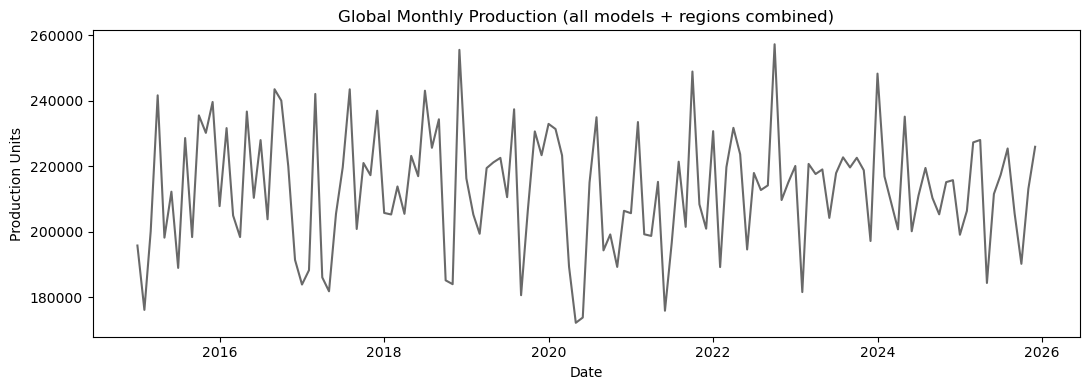

slength: 132 months


In [21]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

ts = df_enc.groupby('Date')['Production_Units'].sum().asfreq('MS')

plt.figure(figsize=(11, 4))
plt.plot(ts.index, ts.values, color='dimgray')
plt.title('Global Monthly Production (all models + regions combined)')
plt.xlabel('Date')
plt.ylabel('Production Units')
plt.tight_layout()
plt.show()

print(f'series length: {len(ts)} months')

In [22]:
train = ts.iloc[:-6]
test  = ts.iloc[-6:]

for order in [(1,1,0), (1,1,1), (2,1,1)]:
    m  = ARIMA(train, order=order).fit()
    fc = m.forecast(steps=6)
    mae = np.mean(np.abs(fc.values - test.values))
    print(f'ARIMA{order}  AIC={m.aic:.1f}  MAE={mae:,.0f} units')

ARIMA(1, 1, 0)  AIC=2874.6  MAE=13,541 units
ARIMA(1, 1, 1)  AIC=2869.4  MAE=11,131 units
ARIMA(2, 1, 1)  AIC=2871.1  MAE=11,341 units


(1,1,1) has the best AIC and also lower MAE so going with this one

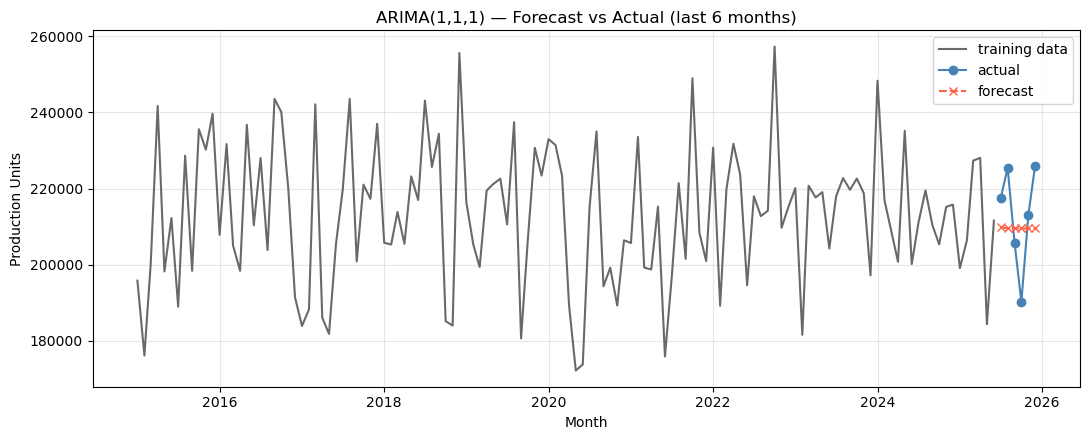

MAE: 11,131 units

                 Forecast  Actual         Error
Date                                           
2025-07-01  209846.111940  217409  -7562.888060
2025-08-01  209571.378044  225466 -15894.621956
2025-09-01  209527.543189  205573   3954.543189
2025-10-01  209520.549168  190202  19318.549168
2025-11-01  209519.433245  213112  -3592.566755
2025-12-01  209519.255195  225981 -16461.744805


In [23]:
mod = ARIMA(train, order=(1,1,1))
res = mod.fit()

fc = res.forecast(steps=6)
fc.index = test.index

plt.figure(figsize=(11, 4.5))
plt.plot(train.index, train.values, color='dimgray', label='training data')
plt.plot(test.index,  test.values,  color='steelblue', marker='o', label='actual')
plt.plot(fc.index,    fc.values,    color='tomato', linestyle='--', marker='x', label='forecast')
plt.title('ARIMA(1,1,1) — Forecast vs Actual (last 6 months)')
plt.xlabel('Month')
plt.ylabel('Production Units')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(fc.values - test.values))
print(f'MAE: {mae:,.0f} units')
print()
comp = pd.DataFrame({'Forecast': fc.values, 'Actual': test.values}, index=test.index)
comp['Error'] = comp['Forecast'] - comp['Actual']
print(comp)